In [ ]:
# Import Required Libraries

# Data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)



# **Task 1 – Load the Dataset**

In [ ]:
# Load the CSV file into a pandas DataFrame
da = pd.read_csv("/content/loan_approval.csv")


In [ ]:
data=da.copy()

# **Data Overview**

In [ ]:
# Display the first 10 rows
print(data.head(10))

              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   
5   Darren Roberts   Port Jesseville   62098           689        19217   
6       Holly Wood       Lake Joseph   59256           373        40920   
7  Nicholas Martin        Nelsonside   48289           524        45866   
8      Patty Perez   Port Leslieview  126530           367        14826   
9       Emily Rios    Wilkersonmouth   43434           446        18359   

   years_employed  points  loan_approved  
0              27      50              0  
1              28      55              0  
2              13      45              0  
3 

# **Task 2 – Understand the Dataset**

In [ ]:
#  Check dataset shape (rows, columns)
print("Dataset Shape:", data.shape)

Dataset Shape: (2000, 8)


In [ ]:
#  Display the size of the data
print("\nsize:")
print(data.size)



size:
16000


In [ ]:
# Check data types and basic info
print("\nDataset Info:")
data.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


# **Statistical Descriptive**

In [ ]:
# Display statistical Descriptive of numerical columns
print("\nStatistical Descriptives:")
print(data.describe())


Statistical Descriptives:
              income  credit_score   loan_amount  years_employed       points  \
count    2000.000000   2000.000000   2000.000000     2000.000000  2000.000000   
mean    90585.977000    573.946000  25308.503000       20.441000    56.680000   
std     34487.874907    160.564945  14207.320147       11.777813    18.638033   
min     30053.000000    300.000000   1022.000000        0.000000    10.000000   
25%     61296.250000    433.000000  12748.750000       10.000000    45.000000   
50%     90387.500000    576.000000  25661.500000       21.000000    55.000000   
75%    120099.750000    715.000000  37380.500000       31.000000    70.000000   
max    149964.000000    850.000000  49999.000000       40.000000   100.000000   

       loan_approved  
count     2000.00000  
mean         0.43950  
std          0.49645  
min          0.00000  
25%          0.00000  
50%          0.00000  
75%          1.00000  
max          1.00000  


In [ ]:
data.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [ ]:
data.duplicated().sum() # checks for duplicated values

np.int64(0)

In [ ]:
data.dtypes # checks all are numeric data

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,int64


# **Task 3 – Exploratory Data Analysis (EDA)**

In [ ]:
# Select only numeric columns (excluding target)
numeric_cols = ["income", "credit_score", "loan_amount",
                "years_employed", "points"]

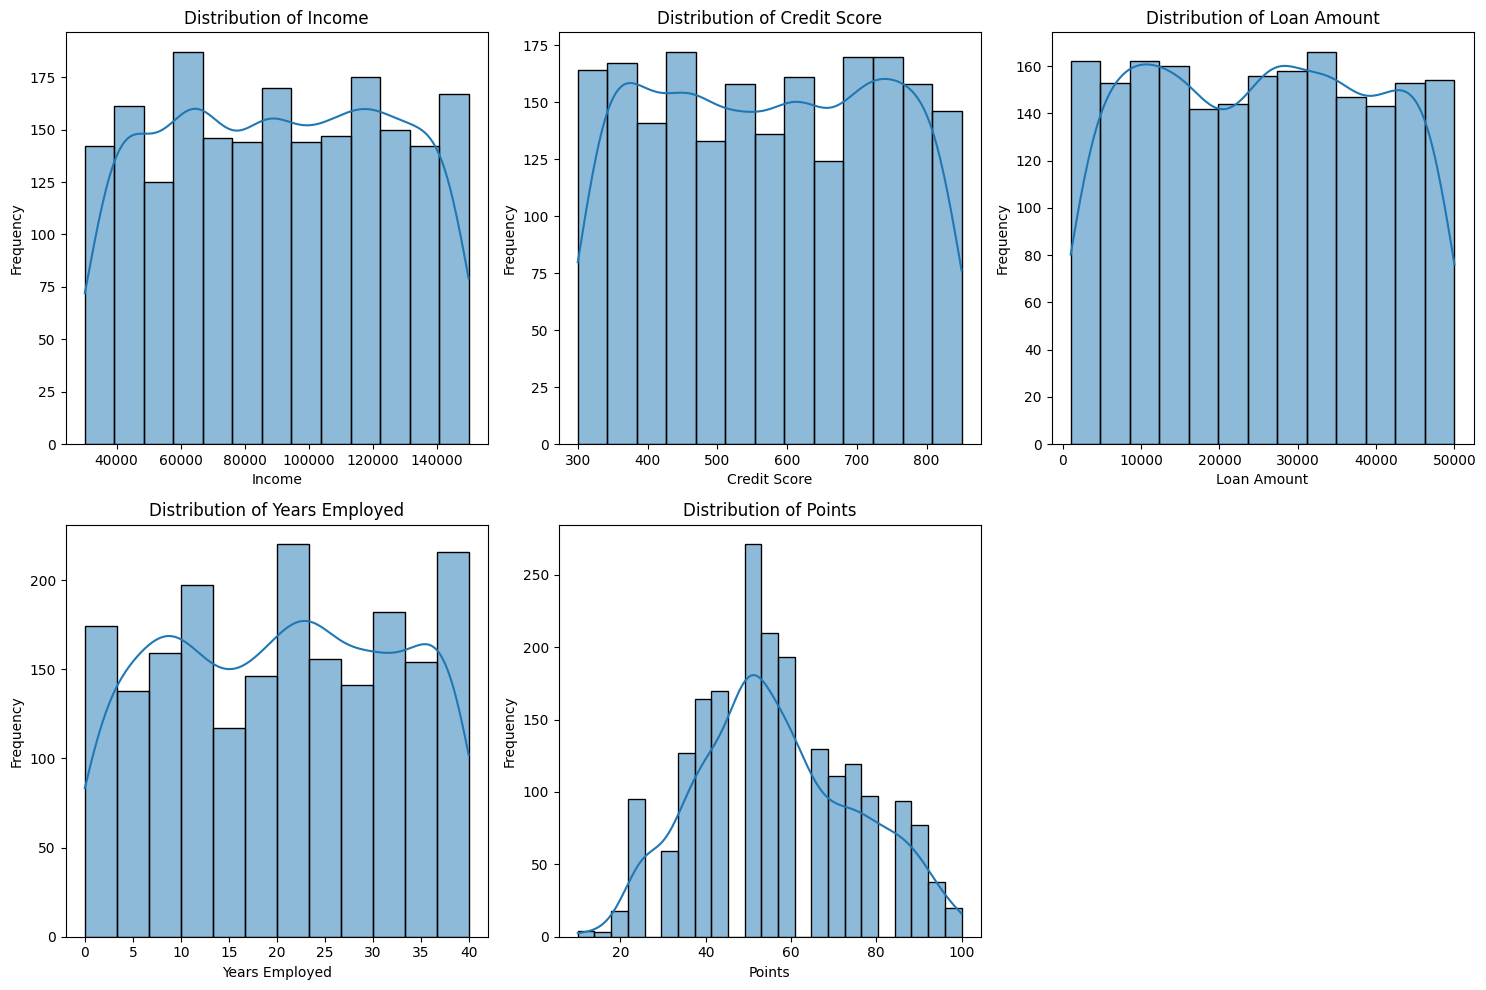

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)  # Adjust subplot grid as needed, e.g., 2 rows, 3 columns
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# **Feature-wise Inference**
**Income Distribution**

* Income ranges from ~30,000 to 150,000

* Distribution is fairly uniform

*  No heavy skewness

* Most applicants fall between 60,000–120,000

**📌 Inference:**

Income is evenly spread across applicants. No extreme concentration in one income range.

**Credit Score Distribution**

* Range: 300 to 850

* Fairly uniform distribution

* No strong skewness

**📌 Inference:**

Applicants have varied credit scores, providing good variability for model learning.

**Loan Amount Distribution**

* Range: 1,000 to 50,000

* Values spread across entire range

* Slight uniform pattern

**📌 Inference:**

Loan requests vary significantly, helping model learn risk patterns.

**Years Employed Distribution**

* Range: 0 to 40 years

* Fairly evenly distributed

* No strong skew

**📌 Inference:**

Employment experience varies across applicants, indicating balanced dataset.

**Points Distribution**

* Range: 10 to 100

* Looks closer to normal distribution (bell-shaped)

* Most values between 40–70

**📌 Inference:**

Internal scoring system is centered around mid values and appears normally distributed.

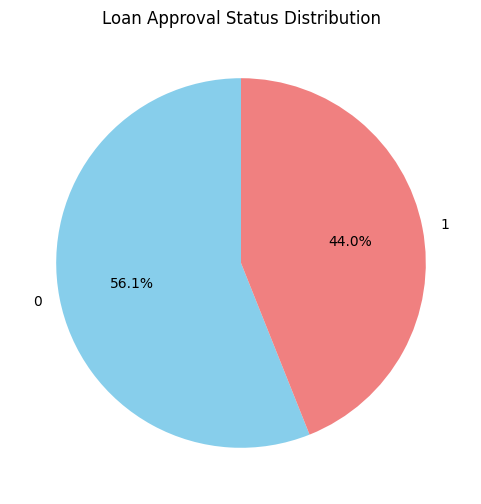

In [ ]:
plt.figure(figsize=(6, 6))
data['loan_approved'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Loan Approval Status Distribution')
plt.ylabel('') # Hide the y-label for a cleaner pie chart
plt.show()

# **Boxplot for All Features**

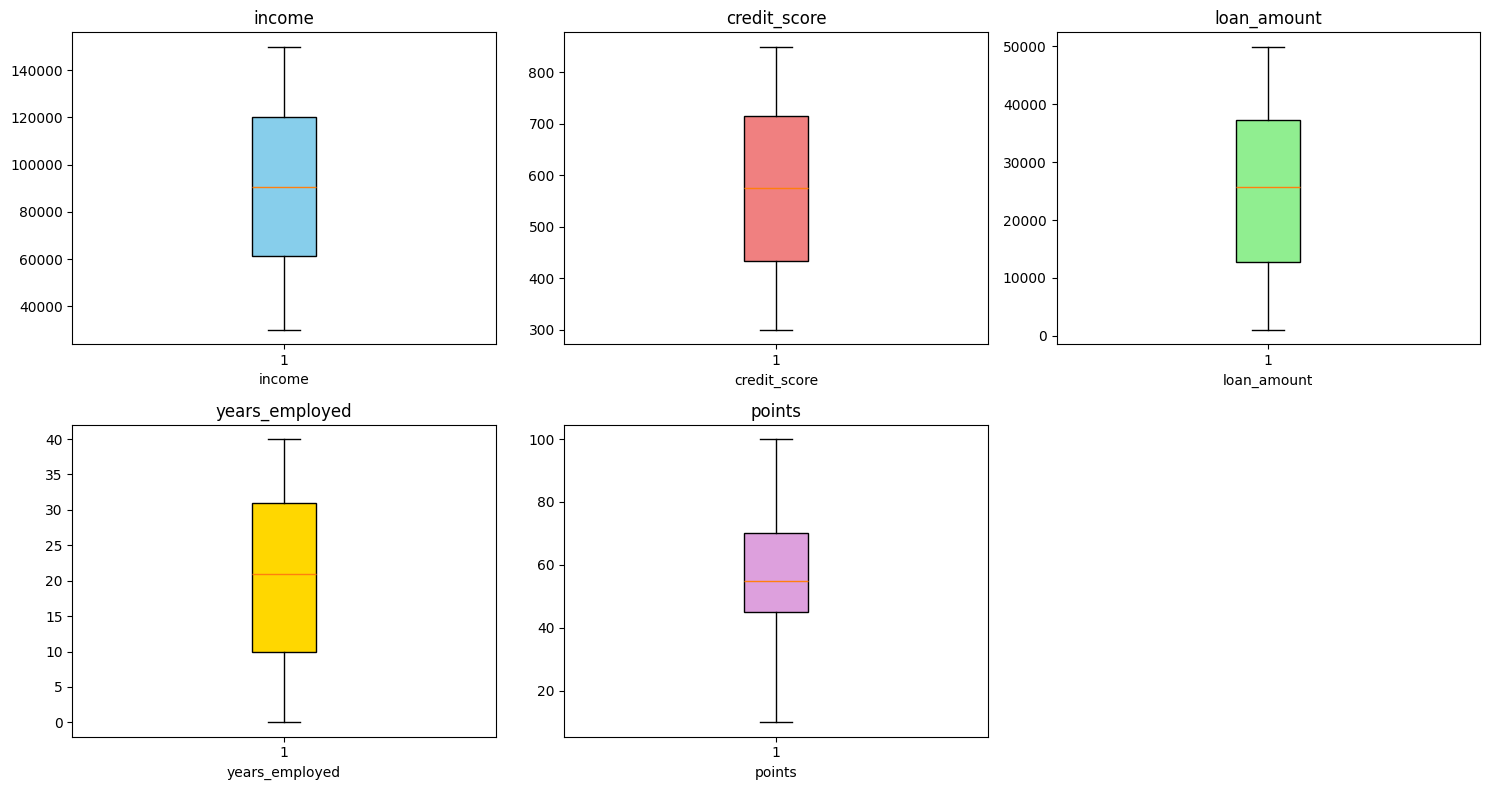

In [ ]:
# Define a list of attractive colors for the box plots
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

# Create subplot grid (2 rows × 3 columns)
plt.figure(figsize=(15,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    # Use patch_artist=True to fill the boxes with color
    bp = plt.boxplot(data[col], patch_artist=True)

    # Apply color to the boxes. Use modulo operator to cycle through colors if there are more columns than colors.
    box_color = colors[(i-1) % len(colors)]
    for box in bp['boxes']:
        box.set(facecolor=box_color)

    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# **Inference**
* Income shows wide distribution with moderate variability among applicants.

* Credit scores are evenly distributed, indicating balanced creditworthiness levels.

* Loan amounts vary significantly, suggesting diverse borrowing needs.

* Years of employment are well spread, showing applicants have varied work experience.

* Internal points are moderately distributed and likely play a strong role in loan approval decisions.

* No extreme outliers are observed in major financial features.

* Overall, the dataset shows good variability and is suitable for Logistic Regression modeling.

# **Correlation Heatmap**

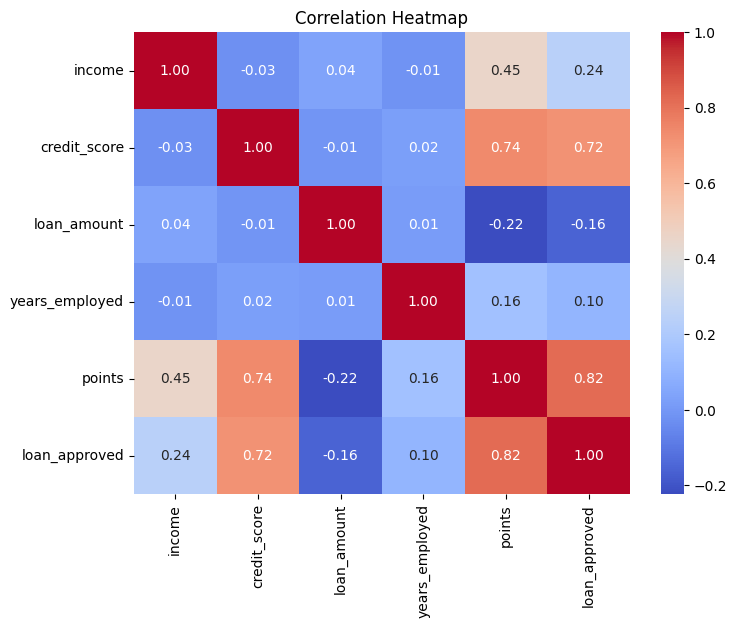

In [ ]:
numeric_df = data.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# **Correlation with Loan Approval**
* Points (0.82) → Strong positive correlation → Most influential feature.

* Credit Score (0.72) → Strong positive correlation → Highly impacts approval.

* Income (0.24) → Weak positive correlation → Slight influence.

* Years Employed (0.10) → Very weak positive correlation.

* Loan Amount (-0.16) → Weak negative correlation → Higher loan reduces approval chance slightly.

# **Task 4 - Train–Test Split**

In [ ]:
# Drop unnecessary columns first (if not done already)
data = data.drop(["name", "city"], axis=1)

# Define Features and Target
X = data.drop("loan_approved", axis=1)
y = data["loan_approved"]

In [ ]:
# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,   # 20% testing data
    random_state=42   # for reproducibility
)


In [ ]:
X_train.head(5)

,income,credit_score,loan_amount,years_employed,points
968,49973,464,22397,24,25
240,70306,508,22644,5,35
819,88446,798,17896,21,85
692,70538,367,13343,29,45
420,96562,763,8472,6,85


In [ ]:
y_train.head(5)

,loan_approved
968,0
240,0
819,1
692,0
420,1


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 5)
X_test shape: (400, 5)
y_train shape: (1600,)
y_test shape: (400,)


# **Task 5 – Feature Scaling (Using StandardScaler)**

# **Why Feature Scaling is Important?**

In our dataset, features like:

Income → values in thousands (e.g., 90000)

Credit_score → 300–850

Loan_amount → 1000–50000

Years_employed → 0–40

These are in different ranges.

# **🔥 Problem Without Scaling:**

Logistic Regression calculates weights using distance-based optimization.
If one feature has very large values (like Income), it can:

     Dominate other features

     Slow down convergence

     Reduce model performance

# **What StandardScaler Does**

It converts data into:


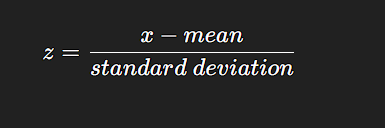
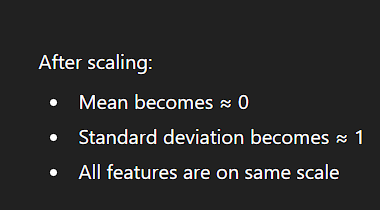

In [ ]:
# Create StandardScaler object
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data (do NOT fit again)
X_test_scaled = scaler.transform(X_test)

# Check shape
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (1600, 5)
Scaled X_test shape: (400, 5)


# **The view of the Dataset after Scaling.**

In [ ]:
# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Convert scaled array back to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Select first 5 rows for comparison
before_scaling = X_train.head().reset_index(drop=True)
after_scaling = X_train_scaled_df.head().reset_index(drop=True)

# Combine both tables side by side
comparison_table = pd.concat(
    [before_scaling.add_suffix(" (Before)"),
     after_scaling.add_suffix(" (After)")],
    axis=1
)

# Display comparison table
comparison_table

,income (Before),credit_score (Before),loan_amount (Before),years_employed (Before),points (Before),income (After),credit_score (After),loan_amount (After),years_employed (After),points (After)
0,49973,464,22397,24,25,-1.170183,-0.675797,-0.217638,0.293376,-1.675295
1,70306,508,22644,5,35,-0.580842,-0.404008,-0.200153,-1.317359,-1.145034
2,88446,798,17896,21,85,-0.055065,1.387327,-0.536250,0.039050,1.506274
3,70538,367,13343,29,45,-0.574118,-1.274967,-0.858543,0.717254,-0.614772
4,96562,763,8472,6,85,0.180173,1.171132,-1.203347,-1.232583,1.506274


# **Task 6 – Train Logistic Regression Model**

In [ ]:
# Create Logistic Regression model
model = LogisticRegression()

In [ ]:
# Train the model using scaled training data
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
# Check model coefficients
print("Model Coefficients:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)

Model Coefficients:
[[ 0.32302213  1.11381344 -0.4082414   0.16364219  9.67246195]]

Model Intercept:
[-0.56839742]


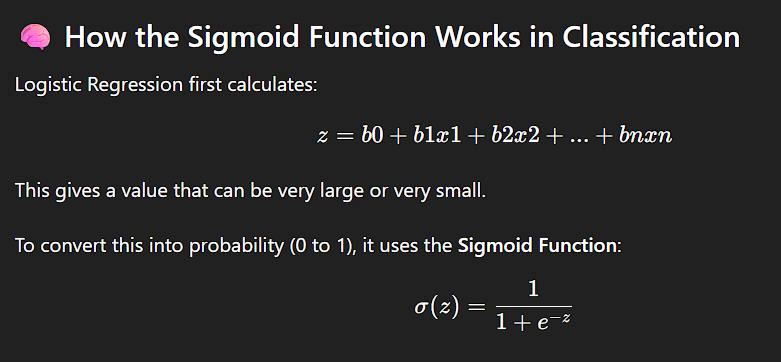

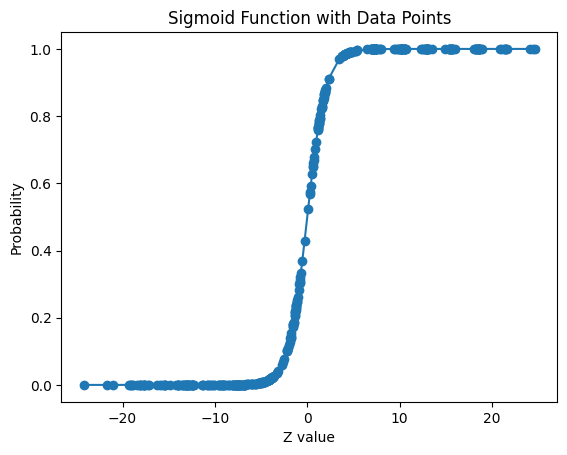

In [ ]:
# Get raw linear output
z = model.decision_function(X_test_scaled)

# Apply sigmoid
probabilities = 1 / (1 + np.exp(-z))

# Plot sigmoid curve
z_sorted = np.sort(z)
sigmoid_curve = 1 / (1 + np.exp(-z_sorted))

plt.figure()
plt.plot(z_sorted, sigmoid_curve)

# Add actual data points
plt.scatter(z, probabilities)

plt.xlabel("Z value")
plt.ylabel("Probability")
plt.title("Sigmoid Function with Data Points")
plt.show()

# **Task 7 – Make Predictions**

In [ ]:
# Make predictions on test data

# Predict class labels (0 or 1)
y_pred = model.predict(X_test_scaled)

# Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 Predictions:", y_pred[:10])
print("First 10 Probabilities:", y_prob[:10])

First 10 Predictions: [0 1 1 1 1 1 0 1 0 1]
First 10 Probabilities: [0.14574818 0.99999985 0.99994874 0.99044335 0.99963392 0.78079242
 0.25381248 0.99229983 0.23717476 0.99996236]


# **What This Does**

predict() → Gives final class (0 = Rejected, 1 = Approved)

predict_proba() → Gives probability of approval

If probability ≥ 0.5 → Approved
Else → Rejected

# **Task 8 – Model Evaluation**

# **Accuracy Score**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


# **Confusion Matrix**

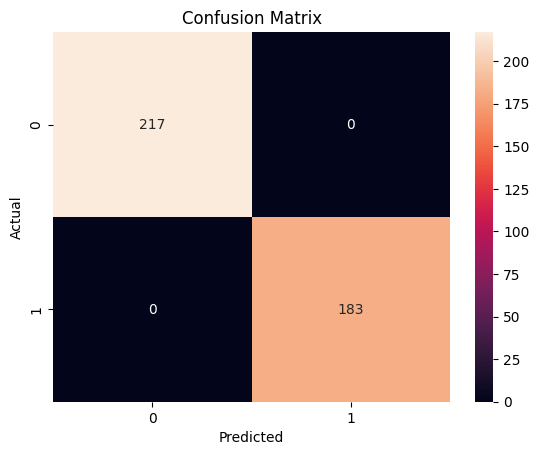

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Classification Report**

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



# **ROC Curve**

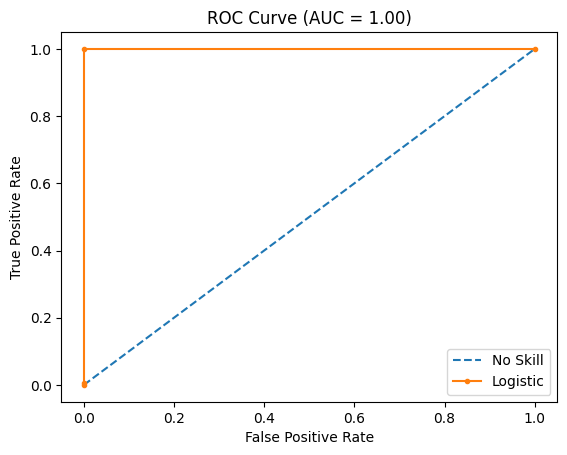

AUC Score: 1.0


In [ ]:
# Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# No-skill probabilities (all zeros baseline)
ns_probs = np.zeros(len(y_test))
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)

# Plot ROC Curve
plt.figure()

# No Skill line
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')

# Logistic model curve
plt.plot(fpr, tpr, marker='.', label='Logistic')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (AUC = %.2f)' % auc_score)
plt.legend()
plt.show()

print("AUC Score:", auc_score)

# **Task 10 - Testing the Model with Sample Applicant Data**

In [ ]:
# 3 example applicants
# Order: [Income, Credit_score, Loan_amount, Years_employed, Points]

example_inputs = np.array([
    [113810,389,39698,27,50],   # Strong candidate
    [44592,729,15446,28,55],     # Moderate candidate
    [33278,584,11189,13,45]      # Risky candidate
])

# Scale inputs
example_scaled = scaler.transform(example_inputs)

# Predict
predictions = model.predict(example_scaled)
probabilities = model.predict_proba(example_scaled)[:, 1]

# Display results
for i in range(len(example_inputs)):
    print(f"\nApplicant {i+1}")
    print("Input:", example_inputs[i])
    print("Prediction (0=Reject, 1=Approve):", predictions[i])
    print("Approval Probability:", round(probabilities[i], 3))


Applicant 1
Input: [113810    389  39698     27     50]
Prediction (0=Reject, 1=Approve): 0
Approval Probability: 0.005

Applicant 2
Input: [44592   729 15446    28    55]
Prediction (0=Reject, 1=Approve): 0
Approval Probability: 0.413

Applicant 3
Input: [33278   584 11189    13    45]
Prediction (0=Reject, 1=Approve): 0
Approval Probability: 0.001


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# **📄 Project Conclusion**

This project successfully implemented a Loan Approval Prediction system using Logistic Regression.
The dataset consisted of financial and employment-related features such as income, credit score, loan amount, years employed, and evaluation points.
Feature scaling was applied using StandardScaler to normalize input variables.
The dataset was split into 80% training and 20% testing data.
The model was evaluated using Accuracy, Confusion Matrix, Classification Report, and ROC Curve.
The results indicate that Logistic Regression effectively predicts loan approval based on applicant financial stability.
This model can help financial institutions automate loan approval decisions and reduce risk.